Movie Classification

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import dateutil
import random
import math

In [2]:
movies = pd.read_csv('https://github.com/YData123/sds265-sp26/raw/main/assignments/assn1/movies.csv')
movies.head(10)

,Title,Genre,Year,Rating,# Votes,# Words,i,the,to,a,...,foster,pub,vegetarian,garrison,grammoo,chimney,bikini,richter,psychopath,fling
0,the terminator,action,1984,8.1,183538,1849,0.040022,0.043807,0.025419,0.024878,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,batman,action,1989,7.6,112731,2836,0.051481,0.033850,0.023977,0.028209,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,tomorrow never dies,action,1997,6.4,47198,4215,0.028707,0.054330,0.030368,0.021827,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000237,0.0
3,batman forever,action,1995,5.4,77223,3032,0.036609,0.042216,0.020449,0.031003,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,supergirl,action,1984,4.1,6576,3842,0.041905,0.032275,0.028891,0.026288,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
5,the avengers,action,1998,3.4,21519,3586,0.036810,0.033463,0.024819,0.029002,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000279,0.0
6,natural born killers,action,1994,7.1,73047,5129,0.028271,0.047378,0.022032,0.027296,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
7,airplane ii: the sequel,romance,1982,5.8,15210,2328,0.027921,0.048969,0.035223,0.025773,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
8,willow,romance,1988,7.1,33506,2006,0.038883,0.028913,0.030409,0.030409,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
9,fast times at ridgemont high,romance,1982,7.2,31710,4703,0.047629,0.027217,0.030619,0.018711,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


In [3]:
movies.iloc[123,[0, 1, 2, 3, 4, 5, 10, 30, 5005]]

Title      the matrix
Genre          action
Year             1999
Rating            8.7
# Votes        389480
# Words          3792
it           0.030327
not          0.008703
fling             0.0
Name: 123, dtype: object

In [4]:
np.linspace(1,1001,5)

array([1.000e+00, 2.510e+02, 5.010e+02, 7.510e+02, 1.001e+03])

In [5]:
print('Words with frequencies:', len(movies.drop(movies.columns[np.arange(6)],axis=1).columns))
print('Movies with genres:', len(movies))

Words with frequencies: 5000
Movies with genres: 236


In [6]:
vocab_mapping = pd.read_csv('https://github.com/YData123/sds265-sp26/raw/main/assignments/assn1/stem.csv')
stemmed = list(movies.drop(movies.columns[np.arange(6)],axis=1).columns)
vocab_table = vocab_mapping[vocab_mapping["Stem"].isin(stemmed)]
vocab_table = vocab_table.sort_values('Stem')
vocab_table.iloc[np.arange(2000, 2010)]

,Stem,Word
2245,coloni,colonys
10851,coloni,colony
25957,coloni,colonial
32608,coloni,colonies
12087,columbia,columbia
37766,columbia,columbias
1523,column,columns
19615,column,column
12629,com,com
34047,coma,comas


In [7]:
stemmed_alternating = vocab_table[vocab_table['Word']=='alternating']['Stem'].item()
stemmed_alternating

'altern'

In [8]:
unstemmed_run = vocab_table[vocab_table['Stem']=='run']['Word']
unstemmed_run

2719         runs
4571      running
5448          run
19975      runned
37194    runnings
Name: Word, dtype: str

In [9]:
training_proportion = 17/20

num_movies = len(movies)
num_train = int(num_movies * training_proportion)
num_test = num_movies - num_train

train_movies = movies.iloc[np.arange(num_train)]
test_movies = movies.iloc[np.arange(num_train, num_movies)]

print("Training: ",   len(train_movies), ";",
      "Test: ",       len(test_movies))

Training:  200 ; Test:  36


<BarContainer object of 2 artists>

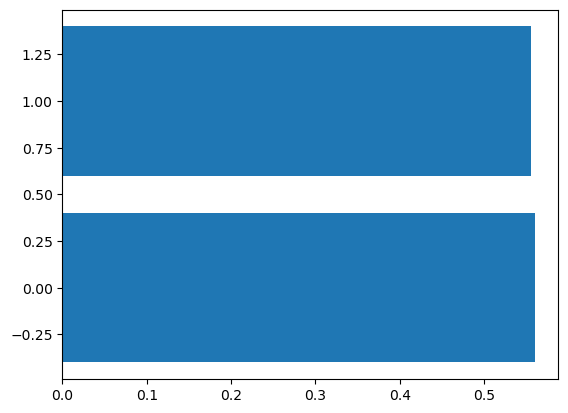

In [10]:
def action_proportion(dataframe):
    """Return the proportion of mcount in a table that have the Action genre."""
    act_prop= len(dataframe[dataframe['Genre']=='action'])/len(dataframe)
    return act_prop

plt.barh([0,1],[action_proportion(train_movies),action_proportion(test_movies)])




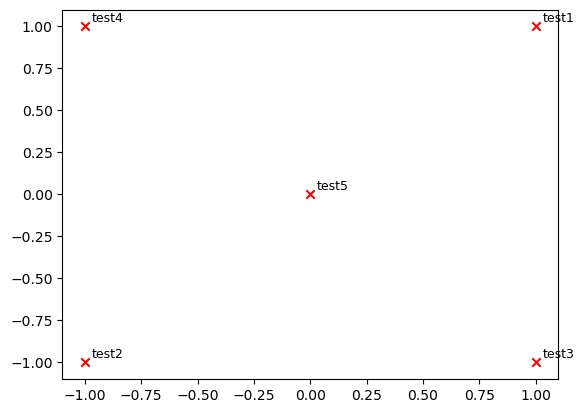

In [11]:
def plot_embeddings(M_reduced, word2Ind, words):
    """
        Plot in a scatterplot the embeddings of the words specified in the list "words".
        Include a label next to each point.
    """
    for word in words:
        x, y = M_reduced[word2Ind[word]]
        plt.scatter(x, y, marker='x', color='red')
        plt.text(x+.03, y+.03, word, fontsize=9)
    plt.show()

M_reduced_plot_test = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1], [0, 0]])
word2Ind_plot_test = {'test1': 0, 'test2': 1, 'test3': 2, 'test4': 3, 'test5': 4}
words = ['test1', 'test2', 'test3', 'test4', 'test5']
plot_embeddings(M_reduced_plot_test, word2Ind_plot_test, words)

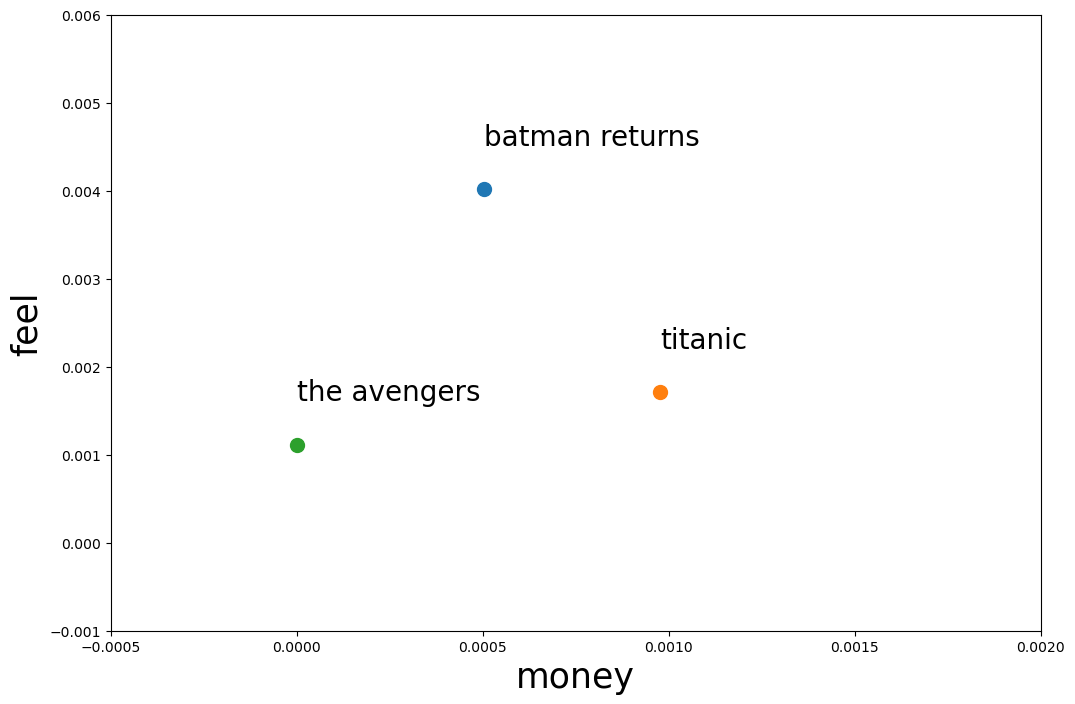

In [31]:
def plot_with_two_features(test_movie, training_movies, x_feature, y_feature):
    """Plot a test movie and training movies using two features."""
    test_row = row_for_title(test_movie)
    test_x = test_row[x_feature].item()
    test_y = test_row[y_feature].item()
    plt.scatter(test_x, test_y, s=100)
    plt.text(test_x, test_y+.0005, test_movie, fontsize=20)
    for movie in training_movies:
        row = row_for_title(movie)
        train_x = row[x_feature].item()
        train_y = row[y_feature].item()
        plt.scatter(train_x, train_y, s=100)
        plt.text(train_x, train_y+.0005, movie, fontsize=20)
    plt.show()

plt.figure(figsize=(12, 8))
plt.xlim(-0.0005, 0.002)
plt.ylim(-0.001, 0.006)
plt.xlabel('money', fontsize=25)
plt.ylabel('feel', fontsize=25)

training = ["titanic", "the avengers"]
plot_with_two_features("batman returns", training, "money", "feel")

In [32]:
def row_for_title(title):
    """Return the row for a title

    """
    return movies[movies["Title"]==title]

In [33]:
batman = row_for_title("batman returns")
avengers = row_for_title("the avengers")
action_distance = ((batman["money"].item()-avengers["money"].item())**2+(batman["feel"].item()-avengers["feel"].item())**2)**(1/2)
print(action_distance)

0.0029437356216700235


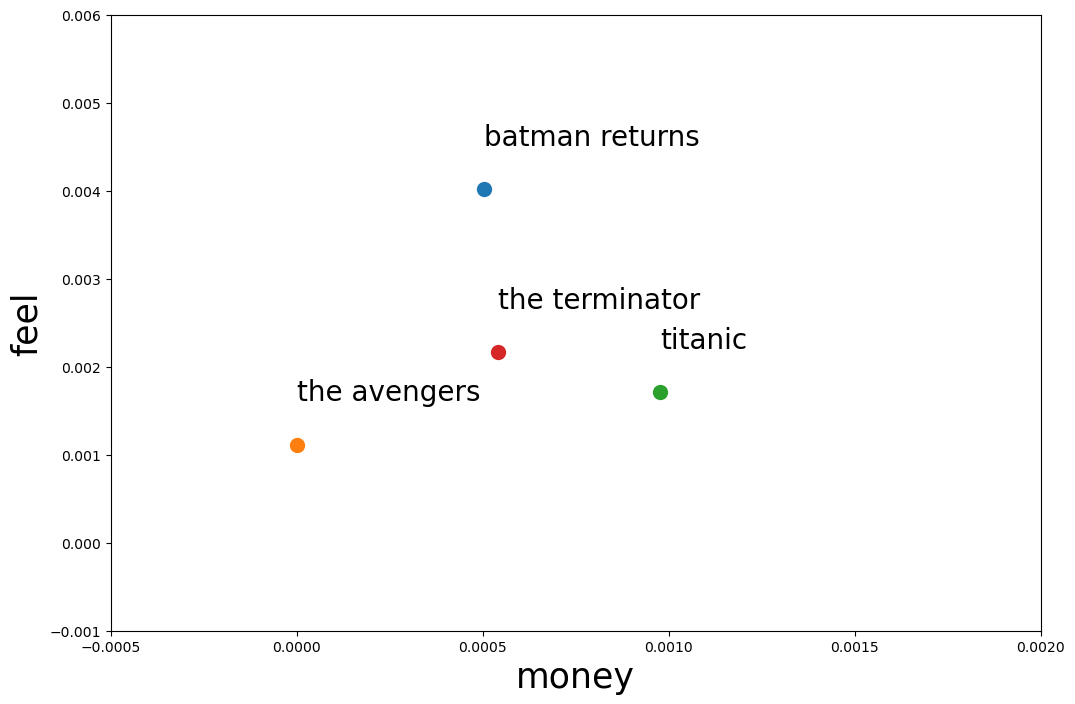

In [34]:
plt.figure(figsize=(12, 8))
plt.xlim(-0.0005, 0.002)
plt.ylim(-0.001, 0.006)
plt.xlabel('money', fontsize=25)
plt.ylabel('feel', fontsize=25)

training = ["the avengers", "titanic", "the terminator"]
plot_with_two_features("batman returns", training, "money", "feel")

In [40]:
def distance_two_features(title0, title1, x_feature, y_feature):
    """Compute the distance between two movies with titles title0 and title1

    Only the features named x_feature and y_feature are used when computing the distance.
    """
    row0 = row_for_title(title0)
    row1 = row_for_title(title1)

    return ((row0[x_feature].item()-row1[x_feature].item())**2+(row0[y_feature].item()-row1[y_feature].item())**2)**(1/2)


for movie in ["the terminator", "the avengers"]:
    movie_distance = distance_two_features(movie, "batman returns", "money", "feel")
    print(movie, 'distance:\t', movie_distance)

the terminator distance:	 0.0018531387547749897
the avengers distance:	 0.0029437356216700235


In [41]:
def distance_from_batman_returns(title):
    """The distance between the given movie and "batman returns", based on the features "money" and "feel".

    This function takes a single argument:
      title: A string, the name of a movie.
    """

    return distance_two_features(title, "batman returns", "money", "feel")

print(distance_from_batman_returns("batman returns"),
distance_from_batman_returns("the avengers"))

0.0 0.0029437356216700235


In [42]:
close_movies = train_movies.copy()

distances_list = []
for title in close_movies["Title"]:
  distances_list.append(distance_from_batman_returns(title))

close_movies['distance from batman'] = distances_list
close_movies = close_movies.sort_values(by='distance from batman').head(7)
close_movies = close_movies[["Title","Genre","money","feel", "distance from batman"]]
close_movies

,Title,Genre,money,feel,distance from batman
61,the bridges of madison county,romance,0.000565,0.004333,0.000323
199,the fisher king,romance,0.000618,0.003504,0.000525
81,broadcast news,romance,0.000137,0.003553,0.000590
24,hellboy,action,0.000000,0.003350,0.000834
120,as good as it gets,romance,0.000523,0.003139,0.000878
193,spider-man,action,0.000347,0.003126,0.000903
111,harold and maude,romance,0.000000,0.003023,0.001112


In [43]:
def most_common(label, dataframe):
    """The most common element in a column of a table.

    This function takes two arguments:
      label: The label of a column, a string.
      dataframe: A dataframe.

    It returns the most common value in that column of that table.
    In case of a tie, it returns any one of the most common values
    """

    return dataframe[label].value_counts().idxmax()

# Calling most_common on your table of 7 nearest neighbors classifies
# "batman returns" as a romance movie, 5 votes to 2.
most_common('Genre', close_movies)

'romance'

In [44]:
def distance(features1, features2):
    """The Euclidean distance between two arrays of feature values."""
    ...

distance_first_to_first = distance(np.array(train_movies.iloc[0,6:]), np.array(test_movies.iloc[0,6]))
distance_first_to_first

In [106]:
# Set my_20_features to a list of 20 features (strings that are column labels)
import random
from sklearn.ensemble import RandomForestRegressor  # or RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# 1. Properly pull your full 2D arrays from the DataFrames
X_train = train_movies.iloc[:, 6:].to_numpy()
X_test = test_movies.iloc[:, 6:].to_numpy()

# Ensure you have your target column array (replace index 5 with your actual target index)
y_train = train_movies.iloc[:, 5].to_numpy()

# Define the selector (it trains the forest internally just to get scores)
# Using RandomForestRegressor assuming you are predicting a continuous value like movie rating/revenue
selector = SelectFromModel(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    threshold="mean"  # Drops any feature with below-average importance
)

# Fit to find the best columns and instantly transform the arrays
selector.fit(X_train,y_train)

feature_mask = selector.get_support()

selected_feature_names = list(train_movies.columns[6:][feature_mask])

print("Saved Column Names:", selected_feature_names)
print("Saved Column Indices:", selected_feature_indices)

# 1. Get the raw importance scores from your fitted Random Forest model
# Note: selector.estimator must already be fitted
all_importances = selector.estimator_.feature_importances_

# 2. Get the indices of the features that survived the initial selection
kept_indices = selector.get_support(indices=True)

# 3. Pull the specific importance scores for just those selected features
selected_importances = all_importances[kept_indices]

# 4. Sort the scores in descending order and grab the top 20 index positions
top_20_relative_indices = np.argsort(selected_importances)[::-1][:20]

# 5. Extract the top 20 feature names from your existing 'selected_features_list'
# We use a list comprehension to easily slice a standard Python list by indices
my_20_features = [selected_feature_names[i] for i in top_20_relative_indices]

# Verify the result
print(f"Number of top features: {len(best_20_features_list)}")
print("Top 20 Best Features:", best_20_features_list)

train_20 = train_movies[my_20_features]
test_20 = test_movies[my_20_features]


Saved Column Names: ['i', 'the', 'it', 'and', 'that', 'of', 'your', 'what', 'in', 'is', 'do', 'dont', 'he', 'for', 'im', 'know', 'be', 'my', 'we', 'on', 'go', 'with', 'are', 'all', 'there', 'about', 'want', 'if', 'here', 'out', 'well', 'think', 'they', 'can', 'one', 'how', 'got', 'at', 'right', 'now', 'look', 'see', 'oh', 'say', 'as', 'tell', 'time', 'good', 'ill', 'ye', 'when', 'yeah', 'from', 'an', 'thing', 'let', 'back', 'make', 'some', 'or', 'would', 'us', 'could', 'didnt', 'way', 'someth', 'had', 'ive', 'talk', 'need', 'sure', 'realli', 'down', 'love', 'littl', 'more', 'our', 'call', 'give', 'mr', 'onli', 'off', 'veri', 'over', 'tri', 'thank', 'peopl', 'day', 'said', 'am', 'sorri', 'even', 'should', 'happen', 'feel', 'becaus', 'thought', 'anyth', 'into', 'id', 'other', 'theyr', 'life', 'ask', 'use', 'befor', 'live', 'still', 'youv', 'help', 'keep', 'than', 'put', 'these', 'must', 'hey', 'around', 'long', 'believ', 'those', 'alway', 'wont', 'place', 'their', 'doe', 'told', 'youll',

In [107]:
print("Movie:")
print(test_movies.iloc[0,[0,1]])
print("Features:")
print(test_20.iloc[0])

Movie:
Title    the mummy
Genre       action
Name: 200, dtype: str
Features:
sit          0.000642
face         0.000642
again        0.000321
need         0.000963
bolshevik    0.000000
morn         0.000321
sell         0.000321
walk         0.000642
week         0.000000
stori        0.000642
bump         0.000000
uhhuh        0.000000
feel         0.000321
would        0.003210
read         0.002889
aw           0.000642
rear         0.000000
complain     0.000000
werent       0.000000
the          0.047833
Name: 200, dtype: float64


In [108]:
def fast_distances(test_row, train_dataframe):
    """An array of the distances between test_row and each row in train_rows.

    Takes 2 arguments:
      test_row: A row of a table containing features of one
        test movie (e.g., test_20.iloc[0]).
      train_table: A table of features (for example, the whole
        table train_20)."""
    assert len(train_dataframe.columns) < 50, "Make sure you're not using all the features of the movies table."

    # Convert DataFrame and Series values to NumPy arrays
    # This avoids potential issues with np.matrix and ensures consistent behavior with np.ndarray
    train_array = train_dataframe.values
    test_row_array = test_row.values

    # Tile the test_row_array to match the number of rows in the training set
    # and broadcast it for element-wise subtraction
    tiled_test_row = np.tile(test_row_array, (train_array.shape[0], 1))

    # Calculate the difference
    diff = tiled_test_row - train_array

    np.random.seed(0) # For tie breaking purposes

    # Calculate the squared Euclidean distances
    # np.square(diff) squares each element
    # .sum(axis=1) sums along the rows, resulting in a 1D array of squared distances
    squared_distances_sum = np.square(diff).sum(axis=1)

    # Take the square root to get the Euclidean distances
    distances = np.sqrt(squared_distances_sum)

    # Add small noise for tie breaking purposes as per original code
    eps = np.random.uniform(size=distances.shape)*1e-10
    distances = distances + eps

    return distances

In [109]:
distances = fast_distances(test_20.iloc[0], train_20)
genre_and_distances = pd.DataFrame({
    "Title": train_movies["Title"],
    "Genre": train_movies["Genre"],
    "Distance": distances
})
genre_and_distances = genre_and_distances.sort_values(by='Distance')
genre_and_distances

,Title,Genre,Distance
11,superman,action,0.003163
7,airplane ii: the sequel,romance,0.003286
60,who framed roger rabbit,action,0.003325
6,natural born killers,action,0.003596
179,indiana jones and the temple of doom,action,0.003639
...,...,...,...
124,eternal sunshine of the spotless mind,romance,0.028097
167,the graduate,romance,0.028191
184,shampoo,romance,0.029586
197,nothing but a man,romance,0.029703


In [110]:
# Set my_assigned_genre to the most common genre among these.
my_assigned_genre = genre_and_distances.head(5)["Genre"].value_counts().idxmax()

# Set my_assigned_genre_was_correct to True if my_assigned_genre
# matches the actual genre of the first movie in the test set.
my_assigned_genre_was_correct = my_assigned_genre == test_movies.iloc[0,1]

print("The assigned genre, {}, was{}correct.".format(my_assigned_genre, " " if my_assigned_genre_was_correct else " not "))

The assigned genre, action, was correct.


In [111]:
from collections import Counter
import pandas as pd

def classify(test_row, train_rows, train_labels, k):
    """Return the most common class among k nearest neighbors to test_row."""
    distances = fast_distances(test_row, train_rows)

    temp_df = pd.DataFrame({
        "Genre": train_labels,
        "Distance": distances
    })
    sorted_df = temp_df.sort_values(by="Distance")
    k_nearest_genres = sorted_df.head(k)["Genre"]
    most_common_genre = Counter(k_nearest_genres).most_common(1)[0][0]
    return most_common_genre

In [112]:
# The sample solution first defined a row called king_kong_features.
king_kong_features = row_for_title("king kong")
# Subset king_kong_features to only include the 20 selected features
king_kong_features_subset = king_kong_features[my_20_features] # Important fix
king_kong_genre = classify(king_kong_features_subset, train_20, train_movies["Genre"], 11)
king_kong_genre

'action'

In [113]:
def classify_feature_row(row):
    return classify(row, train_20, train_movies["Genre"], 11)

# When you're done, this should produce 'Romance' or 'Action'.
classify_feature_row(test_20.iloc[0])

'action'

In [114]:
testguesses = test_movies[my_20_features].apply(classify_feature_row, axis=1)
proportion_correct = (testguesses == test_movies['Genre']).mean()
print(proportion_correct)

0.75


In [115]:
testguesses = test_movies[my_20_features].apply(classify_feature_row, axis=1)
proportion_correct = (testguesses == test_movies['Genre']).mean()
print(f"Accuracy: {proportion_correct:.3f}")  # 0.750

test_movie_correctness = pd.DataFrame({
    'Title': test_movies['Title'],
    'Genre': test_movies['Genre'],
    'Was correct': (testguesses == test_movies['Genre'])  # Fixed: testguesses
})
test_movie_correctness.head(10)

Accuracy: 0.750


,Title,Genre,Was correct
200,the mummy,action,True
201,x-men,action,True
202,men in black,action,True
203,witness,romance,True
204,the bourne supremacy,action,True
205,sleepless in seattle,romance,True
206,king kong,action,True
207,body of evidence,romance,True
208,the hudsucker proxy,romance,False
209,badlands,romance,True
